# 경건하게 새마음 새출발 진수 코드

# 데이터

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp '/content/drive/MyDrive/wrong_joint_predict_data.zip' /content/


In [3]:
!unzip -q /content/wrong_joint_predict_data.zip -d /content


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import zipfile
import os, json, numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as pltr

In [18]:
# #zip 파일 압축 해제
# zip_path = '/content/wrong_joint_predict_data/processed_tensors_Hundred.zip'
# extract_path = '/content/processed_tensors_Hundred'


#학습시키고 싶은 동작에 따라 아래에서 골라서 다른 파일 로드
zip_path = '/content/wrong_joint_predict_data/processed_tensors_Hip Circles.zip'
extract_path = '/content/processed_tensors_HipCircle'

# zip_path = '/content/drive/MyDrive/processed_tensors_Swimming.zip'
# extract_path = '/content/processed_tensors_Swimming'

zip_path = '/content/drive/MyDrive/processed_tensors_Teaser.zip'
extract_path = '/content/processed_tensors_Teaser'

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 압축 해제된 경로 확인
os.listdir(extract_path)

['processed_tensors_Teaser', '__MACOSX']

# 학습


In [19]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import LambdaLR
import math
import os


In [21]:
# pt_path = '/content/processed_tensors_HipCircle/processed_tensors_Hip Circles'
# pt_path = '/content/processed_tensors_Hundred/processed_tensors_Hundred'
pt_path = '/content/processed_tensors_Teaser/processed_tensors_Teaser'
pt_files = sorted(glob.glob(os.path.join(pt_path, '*.pt')))
print(f'총 PT 파일 수 : {len(pt_files)}')

train_paths, val_paths = train_test_split(
    pt_files, test_size=0.2, random_state=42
)

print(f"Train PT 파일 수 : {len(train_paths)} | Val PT 파일 수 : {len(val_paths)}")

총 PT 파일 수 : 1992
Train PT 파일 수 : 1593 | Val PT 파일 수 : 399


In [22]:
import torch
import json
from tqdm import tqdm

train_labels_seq = []

for p in tqdm(train_paths, desc='학습레이블 제작'):
    data = torch.load(p)
    frame_labels = data[1]

    # 시퀀스 전체에서 wrong 관절 1개라도 있으면 → 틀림(0), 아니면 정상(1)
    label = 0 if frame_labels.max().item() > 0 else 1
    train_labels_seq.append(label)

json_save_path = '/content/drive/MyDrive/train_labels_seq_Teaser.json'

with open(json_save_path, 'w') as f:
    json.dump(train_labels_seq, f)

print(f'✅ train_labels_seq 저장 완료 → {json_save_path}')


학습레이블 제작: 100%|██████████| 1593/1593 [00:03<00:00, 488.74it/s]

✅ train_labels_seq 저장 완료 → /content/drive/MyDrive/train_labels_seq_Teaser.json


In [23]:
class FrameSequenceDataset(Dataset):
    def __init__(self, pt_paths, seq_len=30, stride=30):
        self.seq_len = seq_len
        self.stride = stride
        self.samples = []

        for pt_path in tqdm(pt_paths, desc='📦 시퀀스 구성 중'):
            data = torch.load(pt_path)
            total_frames = data[0].shape[0]

            if total_frames < seq_len:
                continue

            for start in range(0, total_frames - seq_len + 1, stride):
                end = start + seq_len
                self.samples.append((pt_path, start))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pt_path, start = self.samples[idx]
        data = torch.load(pt_path)
        frames = data[0]
        frame_labels = data[1]

        seq_frames = frames[start:start+self.seq_len]
        seq_frame_labels = frame_labels[start:start+self.seq_len]

        seq_label = 0 if seq_frame_labels.max().item() > 0 else 1

        return seq_frames, torch.tensor(seq_label, dtype=torch.float32)


In [24]:
train_dataset = FrameSequenceDataset(train_paths, seq_len=30, stride=15)
val_dataset = FrameSequenceDataset(val_paths, seq_len=30, stride=15)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)


📦 시퀀스 구성 중: 100%|██████████| 399/399 [00:00<00:00, 492.07it/s]


In [25]:
class CNNLSTMClassifier(nn.Module):
    def __init__(self, hidden_dim=256, lstm_layers=2, dropout_rate=0.3):
        super(CNNLSTMClassifier, self).__init__()

        base_model = models.resnet18(weights='DEFAULT')
        base_model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.cnn_backbone = nn.Sequential(*list(base_model.children())[:-1])
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout_rate if lstm_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(-1, C, H, W)
        features = self.cnn_backbone(x).view(B, T, -1)

        lstm_out, _ = self.lstm(features)
        last_hidden = lstm_out[:, -1, :]

        out = self.fc(last_hidden)
        return out.squeeze(-1)


In [26]:
import numpy as np

train_labels_seq = np.array(train_labels_seq)
print('Train Data Balance Check')
print(f'Good 비율 : {(train_labels_seq==1).mean():.3f}')
print(f'Wrong 비율: {(train_labels_seq==0).mean():.3f}')


Train Data Balance Check
Good 비율 : 0.595
Wrong 비율: 0.405


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
early_stop_count = 0
early_stop_patience = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

model = CNNLSTMClassifier(hidden_dim=256, lstm_layers=2, dropout_rate=0.5).to(device)
pos_weight = torch.tensor([1.3]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for frames, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
        frames = frames.to(device)
        labels = labels.to(device)

        outputs = model(frames)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.sigmoid(outputs) >= 0.5
        correct += (preds == labels.bool()).sum().item()
        total += frames.size(0)

        train_loss += loss.item() * frames.size(0)

    train_acc = correct / total if total > 0 else 0
    avg_train_loss = train_loss / total if total > 0 else 0

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for frames, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * frames.size(0)

            preds = torch.sigmoid(outputs) >= 0.5
            correct += (preds == labels.bool()).sum().item()
            total += frames.size(0)

    val_acc = correct / total
    avg_val_loss = val_loss / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/Teaser_best_cnn_lstm_model.pth')
        early_stop_count = 0
        print(f'Best model saved at Epoch {epoch+1} with Val Loss: {best_val_loss:.4f}')
    else:
        early_stop_count += 1

    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}')


    if early_stop_count >= early_stop_patience:
        print('EarlyStopping')
        break


사용 디바이스: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/10 [Val]: 100%|██████████| 50/50 [00:03<00:00, 13.80it/s]


Best model saved at Epoch 1 with Val Loss: 0.7688
Epoch [1/10] | Train Loss: 0.7578 | Train Acc: 0.5901 | Val Loss: 0.7688 | Val Acc: 0.6040


Epoch 2/10 [Val]: 100%|██████████| 50/50 [00:03<00:00, 13.48it/s]


Best model saved at Epoch 2 with Val Loss: 0.3548
Epoch [2/10] | Train Loss: 0.5648 | Train Acc: 0.7520 | Val Loss: 0.3548 | Val Acc: 0.8647


...

Epoch [8/10] | Train Loss: 0.1351 | Train Acc: 0.9579 | Val Loss: 0.6830 | Val Acc: 0.7168


Epoch 9/10 [Val]: 100%|██████████| 50/50 [00:03<00:00, 13.55it/s]


Best model saved at Epoch 9 with Val Loss: 0.1095
Epoch [9/10] | Train Loss: 0.1272 | Train Acc: 0.9592 | Val Loss: 0.1095 | Val Acc: 0.9624


Epoch 10/10 [Val]: 100%|██████████| 50/50 [00:03<00:00, 13.58it/s]

Epoch [10/10] | Train Loss: 0.0943 | Train Acc: 0.9730 | Val Loss: 0.1349 | Val Acc: 0.9624


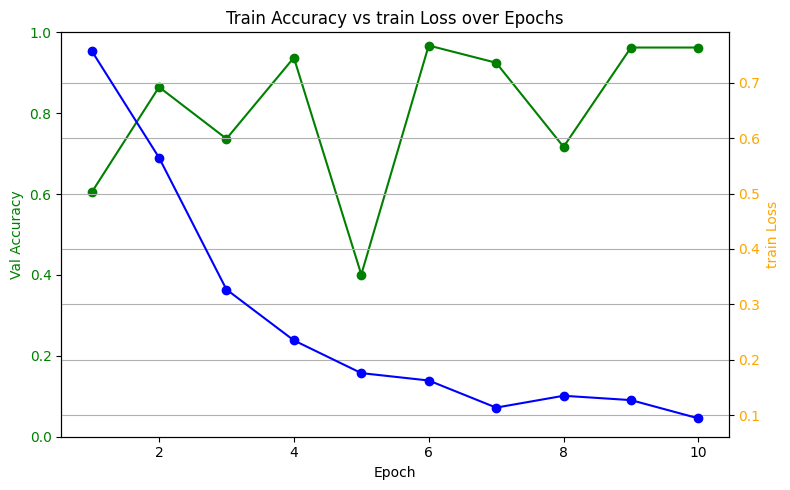

In [28]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(range(1, len(val_accuracies) + 1), val_accuracies, color='green', marker='o', label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Val Accuracy', color='green')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='green')

ax2 = ax1.twinx()
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='blue', label='Train Loss')
ax2.set_ylabel('train Loss', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Train Accuracy vs train Loss over Epochs')
fig.tight_layout()
plt.grid(True)
plt.show()


Accuracy  : 0.9624
Precision : 0.9484
Recall    : 0.9917
F1-score  : 0.9696


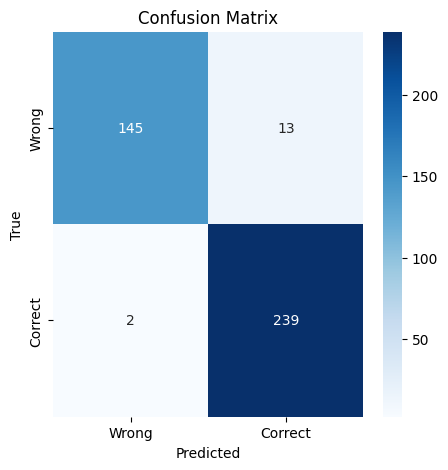

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch


all_labels = []
all_probs = []
all_preds = []


model.eval()

with torch.no_grad():
    for frames, labels in val_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        outputs = model(frames)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int()


        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)


acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Wrong', 'Correct'], yticklabels=['Wrong', 'Correct'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


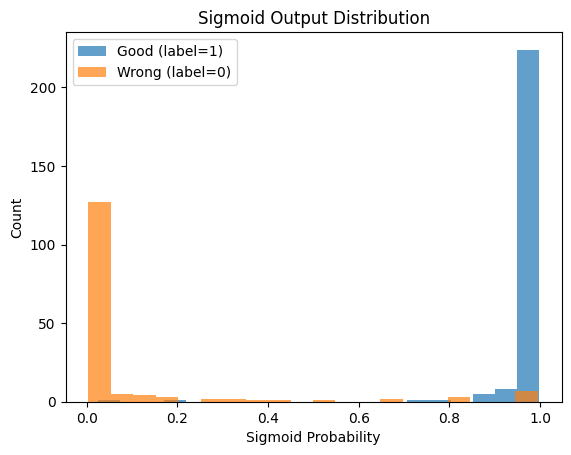

In [30]:

import matplotlib.pyplot as plt

plt.hist([p for l, p in zip(all_labels, all_probs) if l == 1], bins=20, alpha=0.7, label='Good (label=1)')
plt.hist([p for l, p in zip(all_labels, all_probs) if l == 0], bins=20, alpha=0.7, label='Wrong (label=0)')
plt.xlabel('Sigmoid Probability')
plt.ylabel('Count')
plt.legend()
plt.title('Sigmoid Output Distribution')
plt.show()
